Download the dataset

In [1]:
!pip install opendatasets
import opendatasets as od

In [2]:
od.download("https://www.kaggle.com/datasets/miadul/animal-image-classification-5-species")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: adithyanidrajith
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/miadul/animal-image-classification-5-species


100%|██████████| 5.33M/5.33M [00:00<00:00, 1.17GB/s]

In [3]:
IMAGE_SIZE = (224, 224)

In [89]:
import torch
import torchvision
import torchvision.transforms as transforms

train_data = "/content/animal-image-classification-5-species/animals_dataset/test"
test_data = "/content/animal-image-classification-5-species/animals_dataset/train"
validation_data = "/content/animal-image-classification-5-species/animals_dataset/validation"

transform = transforms.Compose(
    [transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

batch_size = 32

trainset = torchvision.datasets.ImageFolder(root=train_data, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.ImageFolder(root=test_data, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=True, num_workers=2)

validationset = torchvision.datasets.ImageFolder(root=validation_data, transform=transform)
validationloader = torch.utils.data.DataLoader(validationset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

classes = trainset.classes

dataiter = iter(trainloader)
images, labels = next(dataiter)

# Check the range of pixel values
print(f"Min pixel value: {images.min()}")
print(f"Max pixel value: {images.max()}")

Min pixel value: -1.0
Max pixel value: 1.0


Get images in a training batch


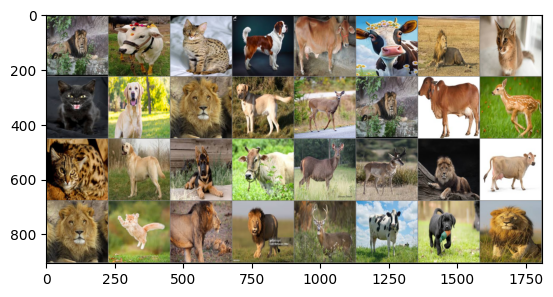

lion  cow   cat   dog   cow   cow   lion  cat   cat   dog   lion  dog   deep  lion  cow   deep  cat   dog   dog   cow   deep  deep  lion  cow   lion  cat   lion  lion  deep  cow   dog   lion 


In [37]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show an image


def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

Implement data augmentation

In [90]:
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1),
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_test_val = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.ImageFolder(root=train_data, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.ImageFolder(root=test_data, transform=transform_test_val)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=True, num_workers=2)

validationset = torchvision.datasets.ImageFolder(root=validation_data, transform=transform_test_val)
validationloader = torch.utils.data.DataLoader(validationset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

print("Data augmentation and dataset loaders reinitialized successfully.")

Data augmentation and dataset loaders reinitialized successfully.


Define a CNN architecture

In [59]:
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.dropout = nn.Dropout(0.25)

        # Calculate the input size for the first fully connected layer dynamically
        # Let's assume input image size is IMAGE_SIZE (e.g., 224x224)
        # Input: 3x224x224
        # After conv1 (no change in size with padding=1): 32x224x224
        # After pool (half size): 32x112x112
        # After conv2 (no change in size with padding=1): 64x112x112
        # After pool (half size): 64x56x56
        # After conv3 (no change in size with padding=1): 128x56x56
        # After pool (half size): 128x28x28
        # The number of features before flattening is 128 * 28 * 28

        # To generalize, we can pass a dummy tensor through the convolutional layers
        # to determine the shape before the first fully connected layer.
        self._to_linear = None
        self.get_conv_output_size()

        self.fc1 = nn.Linear(self._to_linear, 512)
        self.fc2 = nn.Linear(512, len(classes)) # Output to the number of classes

    def get_conv_output_size(self):
        # Pass a dummy input through the convolutional layers
        x = torch.randn(1, 3, IMAGE_SIZE[0], IMAGE_SIZE[1])
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        self._to_linear = x[0].shape[0] * x[0].shape[1] * x[0].shape[2]
        print(f"Calculated input size for FC layer: {self._to_linear}")

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(-1, self._to_linear) # Flatten the tensor
        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Re-instantiate Model
net = Net()

Calculated input size for FC layer: 100352


Define a loss fuction and an optimizer

In [60]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters(), lr=0.001)

Get GPU support

In [61]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
net = net.to(device)

Train the model

In [62]:
train_losses = []
test_accuracies = []
validation_accuracies = [] # Initialize new list for validation accuracies

for epoch in range(15):  # loop over the dataset multiple times

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data
        inputs = inputs.to(device)
        labels = labels.to(device)

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % 2000 == 1999:    # print every 2000 mini-batches
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

    # Calculate and print epoch loss
    epoch_loss = running_loss / len(trainloader)
    train_losses.append(epoch_loss)
    print(f'Epoch {epoch + 1} finished. Average loss: {epoch_loss:.3f}')

    # Evaluate accuracy on the test set after each epoch
    correct = 0
    total = 0
    with torch.no_grad():
        for data in testloader:
            images, labels = data
            images = images.to(device)
            labels = labels.to(device)
            outputs = net(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    test_accuracies.append(accuracy)
    print(f'Accuracy of the network on the test images after epoch {epoch + 1}: {accuracy:.2f} %')

    # Evaluate accuracy on the validation set after each epoch
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for data in validationloader:
            images, labels = data
            images = images.to(device)
            labels = labels.to(device)
            outputs = net(images)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    validation_accuracy = 100 * correct_val / total_val
    validation_accuracies.append(validation_accuracy)
    print(f'Accuracy of the network on the validation images after epoch {epoch + 1}: {validation_accuracy:.2f} %')

print('Finished Training')

Epoch 1 finished. Average loss: 4.552
Accuracy of the network on the test images after epoch 1: 21.12 %
Accuracy of the network on the validation images after epoch 1: 19.28 %
Epoch 2 finished. Average loss: 1.789
Accuracy of the network on the test images after epoch 2: 21.34 %
Accuracy of the network on the validation images after epoch 2: 26.51 %
Epoch 3 finished. Average loss: 1.599
Accuracy of the network on the test images after epoch 3: 22.63 %
Accuracy of the network on the validation images after epoch 3: 19.28 %
Epoch 4 finished. Average loss: 1.607
Accuracy of the network on the test images after epoch 4: 23.71 %
Accuracy of the network on the validation images after epoch 4: 25.30 %
Epoch 5 finished. Average loss: 1.528
Accuracy of the network on the test images after epoch 5: 27.80 %
Accuracy of the network on the validation images after epoch 5: 16.87 %
Epoch 6 finished. Average loss: 1.489
Accuracy of the network on the test images after epoch 6: 32.54 %
Accuracy of the 

Plot training loss, test accuracy and validation acuuracy over the epochs

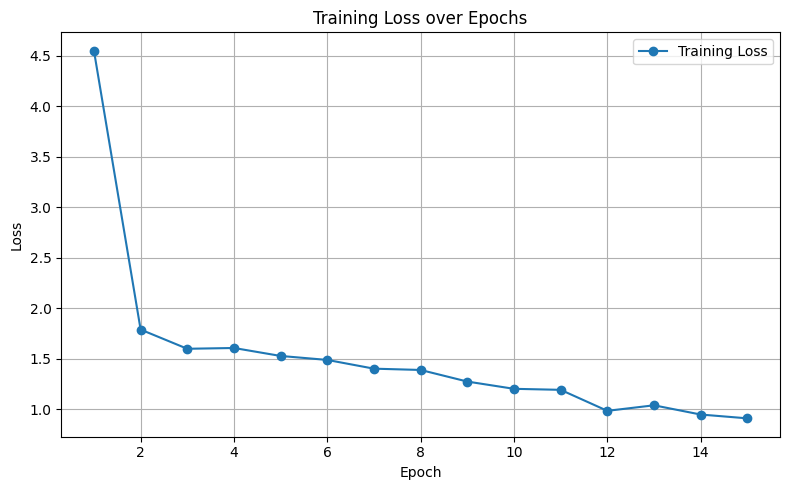

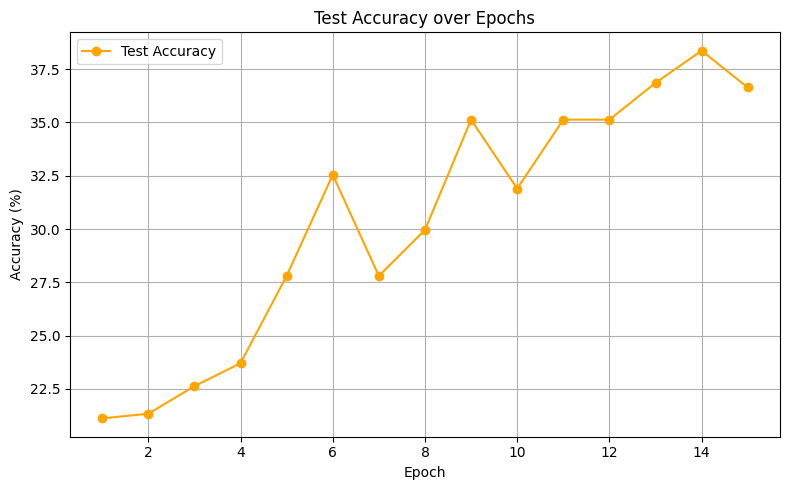

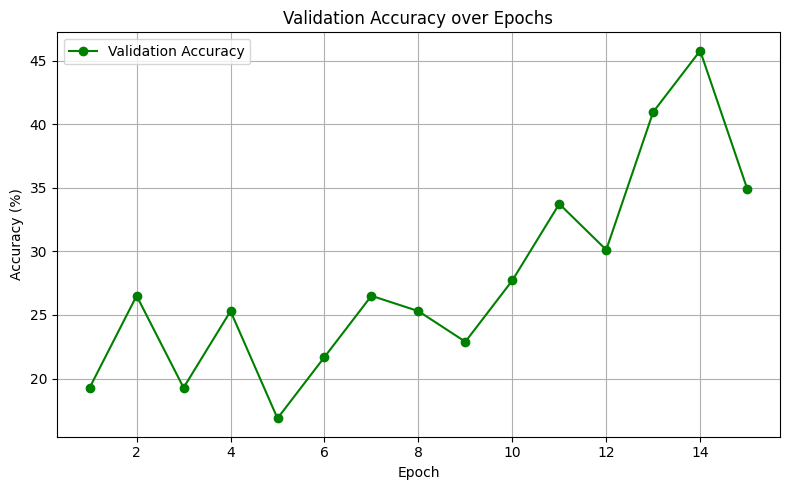

In [63]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

# Plot Training Loss
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, 'o-', label='Training Loss')
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot Test Accuracy
plt.figure(figsize=(8, 5))
plt.plot(epochs, test_accuracies, 'o-', label='Test Accuracy', color='orange')
plt.title('Test Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot Validation Accuracy
plt.figure(figsize=(8, 5))
plt.plot(epochs, validation_accuracies, 'o-', label='Validation Accuracy', color='green')
plt.title('Validation Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Get images in a testing batch

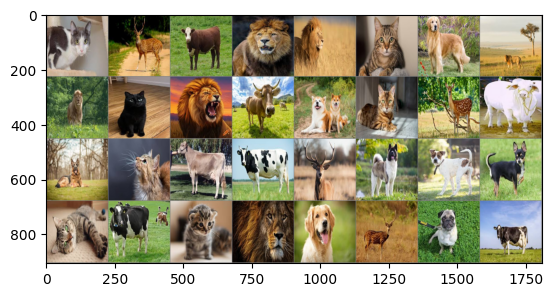

GroundTruth:  cat   deep  cow   lion  lion  cat   dog   lion  lion  cat   lion  cow   dog   cat   deep  cow   dog   cat   cow   cow   deep  dog   dog   dog   cat   cow   cat   lion  dog   deep  dog   cow  


In [67]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show an image
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

dataiter = iter(testloader)
images, labels = next(dataiter)

dataiter = iter(testloader)
images, labels = next(dataiter)

# print images
imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

Get prediction for that images

In [69]:
# Compute outputs for the current batch of images using the loaded_model
images = images.to(device)
with torch.no_grad(): # No need to calculate gradients for inference
    outputs = net(images)

_, predicted = torch.max(outputs, 1)

# Adjust the loop range to the actual number of predictions
print('Predicted: ', ' '.join(f'{classes[predicted[j]]:5s}'
                              for j in range(len(predicted))))

Predicted:  cat   dog   dog   cat   lion  cat   dog   cow   deep  lion  dog   lion  dog   dog   dog   cat   cow   lion  cow   cow   lion  dog   dog   dog   cat   cow   dog   cat   dog   lion  cat   cow  


Calculate the accuracy

In [70]:
correct = 0
total = 0
# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
    for data in testloader:
        images, labels = data
        images = images.to(device)
        labels = labels.to(device)
        # calculate outputs by running images through the network
        outputs = net(images)
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the model on the test images: {100 * correct // total} %')

Accuracy of the model on the test images: 36 %


Accuracy for each class

In [71]:
# prepare to count predictions for each class
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

# again no gradients needed
with torch.no_grad():
    for data in testloader:
        images, labels = data
        images = images.to(device)
        labels = labels.to(device)
        outputs = net(images)
        _, predictions = torch.max(outputs, 1)
        # collect the correct predictions for each class
        for label, prediction in zip(labels, predictions):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1


# print accuracy for each class
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

Accuracy for class: cat   is 30.8 %
Accuracy for class: cow   is 48.8 %
Accuracy for class: deep  is 4.6 %
Accuracy for class: dog   is 45.9 %
Accuracy for class: lion  is 49.4 %


Calculate confusion matrix, f1 score and recall score

In [72]:
from sklearn.metrics import confusion_matrix, f1_score, recall_score
import numpy as np

all_labels = []
all_predictions = []

with torch.no_grad():
    for data in testloader:
        images, labels = data
        images = images.to(device)
        labels = labels.to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)
        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

# Calculate Confusion Matrix
conf_matrix = confusion_matrix(all_labels, all_predictions)
print("Confusion Matrix:")
print(conf_matrix)

# Calculate F1 Score (macro average for multi-class)
f1 = f1_score(all_labels, all_predictions, average='macro')
print(f"\nF1 Score (macro average): {f1:.4f}")

# Calculate Recall Score (macro average for multi-class)
recall = recall_score(all_labels, all_predictions, average='macro')
print(f"Recall Score (macro average): {recall:.4f}")

Confusion Matrix:
[[28 12  2 37 12]
 [12 41  1 14 18]
 [ 6 12  5 37 27]
 [28 13  2 53 15]
 [26  3  2 13 45]]

F1 Score (macro average): 0.3444
Recall Score (macro average): 0.3650


Load a pre-trained model

In [77]:
import torchvision.models as models

# Load the pre-trained ResNet50 model
model_ft = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

print("Pre-trained ResNet50 model loaded successfully.")

Pre-trained ResNet50 model loaded successfully.


In [78]:
import torch.nn as nn

# Freeze all parameters in the network
for param in model_ft.parameters():
    param.requires_grad = False

# Get the number of features in the last layer (fc layer) before the final output
num_ftrs = model_ft.fc.in_features

# Replace the final layer with a new one that has the correct number of output features
# len(classes) is the number of custom animal species (5 in this case)
model_ft.fc = nn.Linear(num_ftrs, len(classes))

# Move the model to GPU if available, else CPU
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model_ft = model_ft.to(device)

print(f"ResNet50 model modified and moved to {device}.")

ResNet50 model modified and moved to cuda:0.


Re-initialize Loss Function and Optimizer

In [84]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_ft.parameters(), lr=0.001)

print("Loss function and optimizer re-initialized successfully.")

Loss function and optimizer re-initialized successfully.


Train the Model with Transfer Learning

In [91]:
train_losses = []
test_accuracies = []
validation_accuracies = []

for epoch in range(10):  # loop over the dataset multiple times for 15 epochs

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data
        inputs = inputs.to(device)
        labels = labels.to(device)

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = model_ft(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        # The original notebook had an i % 2000 == 1999 condition which might not trigger
        # given the dataset size. Let's print progress more frequently or just at the end of epoch.
        # For now, let's keep the epoch summary.

    # Calculate and print epoch loss
    epoch_loss = running_loss / len(trainloader)
    train_losses.append(epoch_loss)
    print(f'Epoch {epoch + 1} finished. Average loss: {epoch_loss:.3f}')

    # Evaluate accuracy on the test set after each epoch
    correct = 0
    total = 0
    with torch.no_grad():
        for data in testloader:
            images, labels = data
            images = images.to(device)
            labels = labels.to(device)
            outputs = model_ft(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    test_accuracies.append(accuracy)
    print(f'Accuracy of the network on the test images after epoch {epoch + 1}: {accuracy:.2f} %')

    # Evaluate accuracy on the validation set after each epoch
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for data in validationloader:
            images, labels = data
            images = images.to(device)
            labels = labels.to(device)
            outputs = model_ft(images)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    validation_accuracy = 100 * correct_val / total_val
    validation_accuracies.append(validation_accuracy)
    print(f'Accuracy of the network on the validation images after epoch {epoch + 1}: {validation_accuracy:.2f} %')

print('Finished Training')

Epoch 1 finished. Average loss: 0.029
Accuracy of the network on the test images after epoch 1: 94.18 %
Accuracy of the network on the validation images after epoch 1: 97.59 %
Epoch 2 finished. Average loss: 0.026
Accuracy of the network on the test images after epoch 2: 93.53 %
Accuracy of the network on the validation images after epoch 2: 95.18 %
Epoch 3 finished. Average loss: 0.020
Accuracy of the network on the test images after epoch 3: 93.75 %
Accuracy of the network on the validation images after epoch 3: 96.39 %
Epoch 4 finished. Average loss: 0.015
Accuracy of the network on the test images after epoch 4: 93.10 %
Accuracy of the network on the validation images after epoch 4: 97.59 %
Epoch 5 finished. Average loss: 0.026
Accuracy of the network on the test images after epoch 5: 93.32 %
Accuracy of the network on the validation images after epoch 5: 95.18 %
Epoch 6 finished. Average loss: 0.021
Accuracy of the network on the test images after epoch 6: 94.18 %
Accuracy of the 

Plot training loss, test accuracy and validation accuracy over the epochs

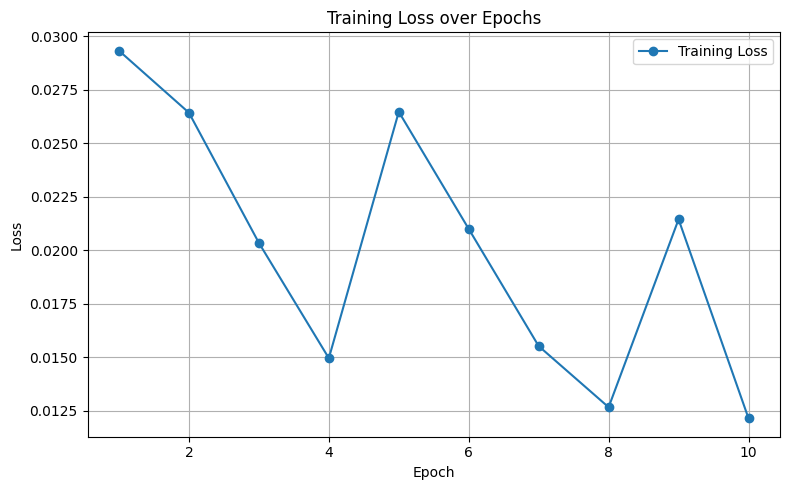

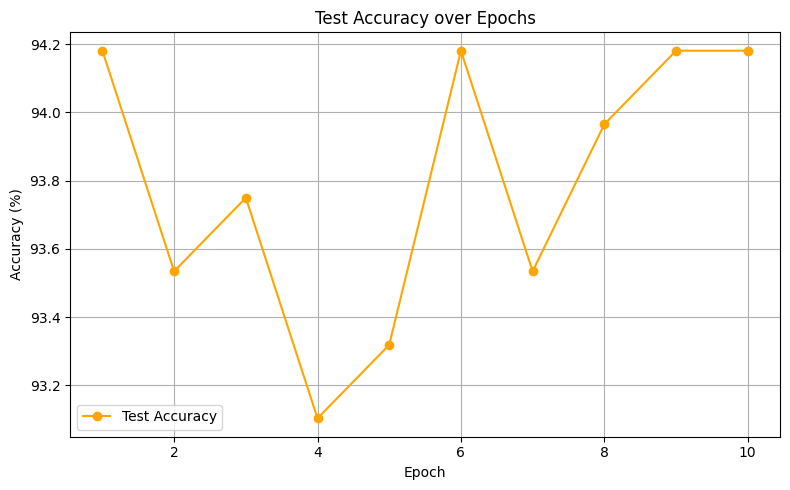

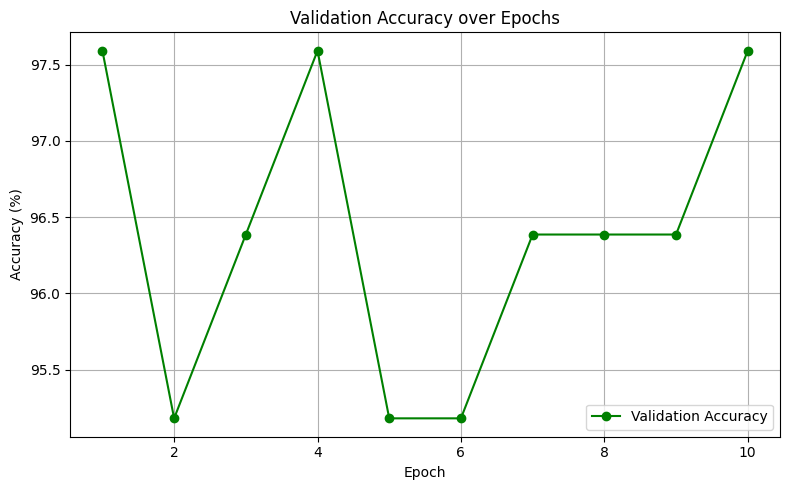

In [92]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

# Plot Training Loss
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, 'o-', label='Training Loss')
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot Test Accuracy
plt.figure(figsize=(8, 5))
plt.plot(epochs, test_accuracies, 'o-', label='Test Accuracy', color='orange')
plt.title('Test Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot Validation Accuracy
plt.figure(figsize=(8, 5))
plt.plot(epochs, validation_accuracies, 'o-', label='Validation Accuracy', color='green')
plt.title('Validation Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Save model

In [93]:
import torch

MODEL_SAVE_PATH = '/content/resnet_model.pth'
torch.save(model_ft.state_dict(), MODEL_SAVE_PATH)

print(f"Model saved to {MODEL_SAVE_PATH}")

Model saved to /content/resnet_model.pth


Load model

In [94]:
import torchvision.models as models
import torch.nn as nn
import torch

# 1. Instantiate a new ResNet50 model with pre-trained weights
loaded_model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# 2. Freeze all parameters of the loaded_model
for param in loaded_model.parameters():
    param.requires_grad = False

# 3. Replace the final fully connected layer
num_ftrs_loaded = loaded_model.fc.in_features
loaded_model.fc = nn.Linear(num_ftrs_loaded, len(classes))

# 4. Move the loaded_model to the appropriate device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
loaded_model = loaded_model.to(device)

# 5. Load the saved state dictionary
loaded_model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))

print("Model loaded successfully and ready for evaluation.")

Model loaded successfully and ready for evaluation.


Evaluate model

In [95]:
from sklearn.metrics import confusion_matrix, f1_score, recall_score
import numpy as np

# 1. Initialize empty lists and dictionaries
all_labels = []
all_predictions = []
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

# 3. Iterate through the testloader in evaluation mode
loaded_model.eval() # Set model to evaluation mode
with torch.no_grad():
    for data in testloader:
        images, labels = data
        # a. Move images and labels to the appropriate device
        images = images.to(device)
        labels = labels.to(device)

        # b. Get model outputs
        outputs = loaded_model(images)

        # c. Obtain predicted labels
        _, predicted = torch.max(outputs, 1)

        # d. Extend all_labels and all_predictions
        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

        # e. Update correct_pred and total_pred for per-class accuracy
        for label, prediction in zip(labels, predicted):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1

# 4. Calculate and print overall accuracy
correct_overall = (np.array(all_predictions) == np.array(all_labels)).sum()
total_overall = len(all_labels)
overall_accuracy = 100 * correct_overall / total_overall
print(f"\nOverall Accuracy of the model on the test images: {overall_accuracy:.2f} %")

# 5. Calculate and print per-class accuracy
print("\nAccuracy for each class:")
for classname, correct_count in correct_pred.items():
    if total_pred[classname] > 0:
        accuracy = 100 * float(correct_count) / total_pred[classname]
        print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')
    else:
        print(f'Accuracy for class: {classname:5s} is N/A (no samples)')

# 7. Calculate and print Confusion Matrix
conf_matrix = confusion_matrix(all_labels, all_predictions)
print("\nConfusion Matrix:")
print(conf_matrix)

# 8. Calculate and print F1 Score (macro average)
f1 = f1_score(all_labels, all_predictions, average='macro')
print(f"\nF1 Score (macro average): {f1:.4f}")

# 9. Calculate and print Recall Score (macro average)
recall = recall_score(all_labels, all_predictions, average='macro')
print(f"Recall Score (macro average): {recall:.4f}")


Overall Accuracy of the model on the test images: 95.91 %

Accuracy for each class:
Accuracy for class: cat   is 100.0 %
Accuracy for class: cow   is 100.0 %
Accuracy for class: deep  is 98.9 %
Accuracy for class: dog   is 83.8 %
Accuracy for class: lion  is 100.0 %

Confusion Matrix:
[[91  0  0  0  0]
 [ 0 86  0  0  0]
 [ 0  1 86  0  0]
 [ 4  2  6 93  6]
 [ 0  0  0  0 89]]

F1 Score (macro average): 0.9603
Recall Score (macro average): 0.9653
